# Preamble

In [7]:
import numpy as np
import scipy.integrate as itg
import matplotlib as mpl
import matplotlib.pyplot as plt
from cycler import cycler

plt.style.use('dark_background')
mpl.rcParams['axes.prop_cycle'] = cycler(color=mpl.color_sequences['Pastel1'])
mpl.rcParams['figure.facecolor'] = 'xkcd:dark'
mpl.rcParams['axes.facecolor'] = 'none'

# Scalar ODE

Bernoulli differential equation: $y' = y - y^3.$ After substitution $v := y^{-2},$ get
$$v' = -2y^{-3} y' = -2 y^{-3} (y - y^3) = 2(1-v).$$
Then
$$1-v = 1-y^{-2} = C\exp(-2t)$$
so
$$y = \pm(1-C\exp(-2t))^{-1/2}.$$
In terms of initial conditions
$$C = 1-y_0^{-2}.$$
Finally
$$y = \frac{\operatorname{sgn} y_0}{\sqrt{1-(1-y_0^{-2})\exp(-2t)}} = \frac{y_0}{\sqrt{1 + (1-y_0^2)(\exp(-2t)-1)}}.$$

In [2]:
def fun(t, y):
    return y * (1.0 - y * y)


def y_exact(t, y0):
    return np.reciprocal(np.sqrt(1.0 + (1.0 - y0*y0) * np.expm1(-2.0*t))) * y0

# Explicit Euler

In [3]:
class ExplicitEulerOdeSolver(itg.OdeSolver):
    def __init__(self, fun, t0, y0, t_bound, vectorized = False, **extraneous):
        itg._ivp.common.warn_extraneous(extraneous)
        super().__init__(fun, t0, y0, t_bound, vectorized,
                         support_complex=True)

    def _step_impl(self):
        success = False
        message = "boo"
        return (success, message)
    
    def _dense_output_impl(self):
        return itg.DenseOutput(t_old, t)

class ExplicitEulerDenseOutput(itg.OdeSolver):
    pass

# Graph of Flow Lines and Euler Polygons

For plotting purposes, assume 1:1 scale. We want to find curves which intersect the family of curves orthogonally. They are the parametric curves $(x(y), y)$ where $x'(y) = -f(y) = y^3 - y.$ Integrating yields:

$$ x(y) = \frac{y^4}{4} - \frac{y^2}{2} + x_0 = \left(\frac{y^2}{2} - 1\right) \frac{y^2}{2} + x_0. $$

The arc-length of this curve from $(x(0), 0)$ to $(x(y), y)$ is:

$$ s(y) = \int_0^y \sqrt{f^2(u) + 1}\ du = \int_0^y \sqrt{f^2(u) + 1}\ du. $$

Inverse of this function $y(s)$ satisfies the following ODE with $y(0) = 0$:

$$ y'(s) = \frac{1}{s'(y(s))} = \frac{1}{\sqrt{f^2(y) + 1}}. $$

/tmp/ipykernel_8764/1471512840.py:6: RuntimeWarning: invalid value encountered in sqrt
  return np.reciprocal(np.sqrt(1.0 + (1.0 - y0*y0) * np.expm1(-2.0*t))) * y0


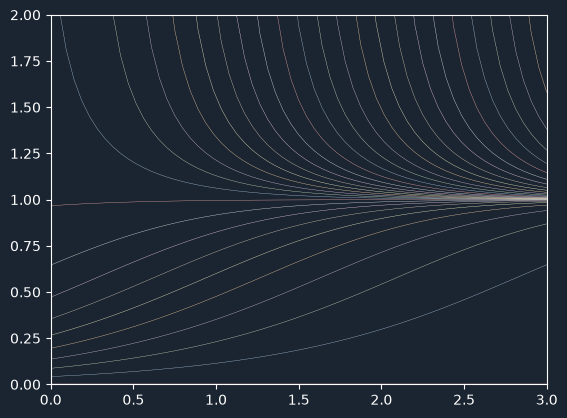

In [ ]:
ts = np.linspace(0.0, 3.0, 65)

fig: plt.Figure
ax: plt.Axes
fig, ax = plt.subplots()
ax.set_xlim(0.0, 3.0)
ax.set_ylim(0.0, 2.0)

# integral of fun gives line that has slope of y at every point of y
# then transform by rotating 90deg CCW to get orthogonal line

def x_fun(y):
    y = 0.5 * y * y
    return (y - 1.0) * y

L, _ = itg.quad(lambda u: np.sqrt(fun(0.0, u)**2 + 1.0), 0.0, 2.0)
y0s = itg.solve_ivp(
    lambda t, y: np.reciprocal(np.sqrt(fun(0.0, y)**2 + 1.0)),
    (0.0, L),
    [0.0],
    t_eval=np.linspace(0.0, L, 33),
).y[0]
t0s = x_fun(y0s) + 1.0

for t0, y0 in np.column_stack((t0s, y0s)):
    ye = y_exact(ts - t0, y0)
    ax.plot(ts, ye, linewidth='0.25')

plt.show()


# First cut of scalar ODE

/tmp/ipykernel_8764/2388363998.py:36: RuntimeWarning: divide by zero encountered in log
  ]).T, np.log(info['global_error'][:-1]))


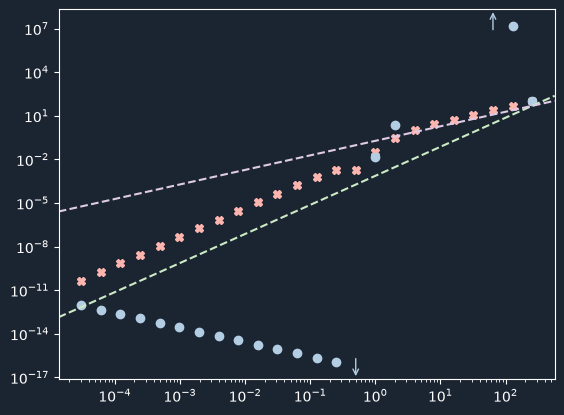

(array([nan, nan]),
 array([nan]),
 np.int32(2),
 array([25.87116246,  4.08755578]))

In [8]:

def ivp_explicit_euler(f, tbounds, u0, num_steps):
    t0, t1 = tbounds
    h = (t1 - t0) / num_steps

    ts = np.linspace(t0, t1, num_steps + 1)
    us = np.array([u := u0, *(u := u + h * f(t, u) for t in ts[:-1])])
    return (ts, us)


def ivp_explicit_euler_error_vs_step_size(f, tbounds, u0, u_exact, norm, num_stepss):
    t0, t1 = tbounds

    @np.vectorize(otypes=[[('step_size', float),
                           ('local_error', float),
                           ('global_error', float)]])
    def analysis_info(num_steps):
        t, u_est = ivp_explicit_euler(f, tbounds, u0, num_steps)
        step_size = (t1 - t0) / num_steps
        local_error = norm(u_exact(t[1], u0) - u_est[1])
        global_error = norm(u_exact(t[-1], u0) - u_est[-1])
        return (step_size, local_error, global_error)

    error_analysis_info = analysis_info(num_stepss)
    error_analysis_info.sort(order=['step_size'])
    return error_analysis_info


u0 = 0.5
tbounds = (0.0, 256.0)
info = ivp_explicit_euler_error_vs_step_size(
    fun, tbounds, u0, y_exact, np.abs, 1 << np.arange(24))

gerr_lstsq_res = np.linalg.lstsq(np.array([
        np.log(info['step_size'][:-1]),
        np.ones_like(info['step_size'][:-1]),
    ]).T, np.log(info['global_error'][:-1]))



fig, ax = plt.subplots()
ax1 = ax
ax2 = ax
fig.subplots_adjust(hspace=0.05)

ax1.set_xscale('log')
ax1.set_yscale('log')
# ax2.set_yscale('log')
# ax1.spines.bottom.set_visible(False)
# ax2.spines.top.set_visible(False)
# ax1.xaxis.tick_top()
# d = .5
# kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
#               linestyle="none", color='white', mec='white', mew=1, clip_on=False)
# ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
# ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)


ax1.plot(info["step_size"], info["local_error"], "C0X")

gerror_nan_mask = np.isnan(info["global_error"])
step_sizes_where_nan = info[gerror_nan_mask]
ginfo = info[np.logical_not(gerror_nan_mask)]

partition_idx = 8
step_sizes_where_zero = ginfo[ginfo["global_error"] == 0.0]["step_size"]

num_big_cut = 1

if num_big_cut > 0:
    big_indices = np.argpartition(ginfo["global_error"], -num_big_cut)[-num_big_cut:]
    big_cutoff = np.min(ginfo["global_error"][big_indices])
    step_sizes_where_big = ginfo["step_size"][big_indices]
    plotted_ginfo = ginfo[ginfo["global_error"] < big_cutoff]
else:
    step_sizes_where_big = []
    plotted_ginfo = ginfo

hs = plotted_ginfo["step_size"]
Es = plotted_ginfo["global_error"]
ax1.plot(hs[partition_idx:], Es[partition_idx:], "C1o")
ax2.plot(hs[:partition_idx], Es[:partition_idx], "C1o")

y_bottom1, y_top1 = ax1.get_ylim()
y_bottom2, y_top2 = ax2.get_ylim()

arrow_len1 = np.exp((1.0/16) * np.log(y_top1 / y_bottom1))
arrow_len2 = np.exp((1.0/16) * np.log(y_top2 / y_bottom2))

for h in step_sizes_where_zero:
    ax2.annotate("", xytext=(h, y_bottom2 * arrow_len2), xy=(h, y_bottom2),
                arrowprops=dict(arrowstyle="->", color="C1"))

for h in step_sizes_where_big:
    ax1.annotate("", xytext=(h, y_top1 / arrow_len1), xy=(h, y_top1),
                arrowprops=dict(arrowstyle="->", color="C1"))

sample_h = plotted_ginfo["step_size"][-1]
len_t = tbounds[1] - tbounds[0]
avg_d2udt2_times_len_t = np.abs(fun(tbounds[1], y_exact(tbounds[1], u0)) - fun(tbounds[0], u0))
avg_d2udt2 = avg_d2udt2_times_len_t / len_t

local_ref_pt1 = np.array([sample_h, 0.5 * avg_d2udt2_times_len_t * sample_h * sample_h / len_t])
local_ref_pt2 = local_ref_pt1 * np.array([0.5, 0.25])
ax.axline(local_ref_pt1, local_ref_pt2, color="C2", linestyle='--')

global_ref_pt1 = np.array([sample_h, 0.5 * avg_d2udt2_times_len_t * sample_h])
global_ref_pt2 = 0.5 * global_ref_pt1
ax.axline(global_ref_pt1, global_ref_pt2, color="C3", linestyle='--')

plt.show()
gerr_lstsq_res

# Matrix differential equations

In [6]:
def make_polar_factor_flow_fun(out_dim):
    def polar_factor_flow_fun(_t, vecX):
        X = np.reshape(vecX, shape=(out_dim, -1))
        XTX = X.T @ X
        return np.reshape(X @ (np.eye(*np.shape(XTX)) - XTX), shape=(-1,))
    return polar_factor_flow_fun

def make_polar_factor_flow_jac(out_dim):
    def polar_factor_flow_jac(_t, vecX):
        X = np.reshape(vecX, shape=(out_dim, -1))
        n, m = X.shape
        dac_dbd = np.multiply.outer(np.eye(n), np.eye(m))
        dbd_Xaj_Xcj = np.multiply.outer(np.eye(m), X @ X.T)
        dac_Xkb_Xkd = np.multiply.outer(np.eye(n), X.T @ X)
        Xad_Xcb = np.multiply.outer(X, X)

        return (
            np.transpose(dac_dbd, (0, 2, 1, 3))
            - np.transpose(dbd_Xaj_Xcj, (2, 0, 3, 1))
            - np.transpose(dac_Xkb_Xkd, (0, 2, 1, 3))
            - np.transpose(Xad_Xcb, (0, 3, 2, 1))
        ).reshape((n * m, n * m))
    return polar_factor_flow_jac

X0 = np.array([
    [.5, .5 * np.sqrt(3.), 0.],
    [-.25 * np.sqrt(3.), .25, .5 * np.sqrt(3)]])
out_dim = X0.shape[0]
polar_factor_flow_fun = make_polar_factor_flow_fun(out_dim)
polar_factor_flow_jac = make_polar_factor_flow_jac(out_dim)
y0 = np.reshape(X0, shape=(-1,))
y1 = itg.solve_ivp(polar_factor_flow_fun, (0.0, 1.0), y0).y[:,-1]
np.reshape(y1, shape=(out_dim, -1))
X1 = np.reshape(y1, shape=(out_dim, -1))

y0jac = polar_factor_flow_jac(0.0, y0)
eig_result = np.linalg.eigh(y0jac)
zero_eigenspace = list(
    map(
        lambda pair: np.reshape(pair[1], shape=(out_dim, -1)),
        filter(
            lambda pair: np.abs(pair[0]) < 1e-6,
            zip(eig_result.eigenvalues, eig_result.eigenvectors.T)
        )
    )
)

# X1, np.reshape(y0jac, (*X0.shape, *X0.shape)), zero_eigenspace, [np.trace(evec @ X0.T) for evec in zero_eigenspace]
eig_result.eigenvalues

array([-2.00000000e+00, -2.00000000e+00, -2.00000000e+00, -2.67837529e-16,
       -1.85071222e-16,  8.81954198e-18])